<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `ExplicitStimulusWhiskerData.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now reproduces the dataset-backed lag search, stimulus-effect, and history-effect workflow with real figures; exact KS traces and coefficient values still vary modestly from MATLAB because the Python GLM backend and plotting defaults are different.


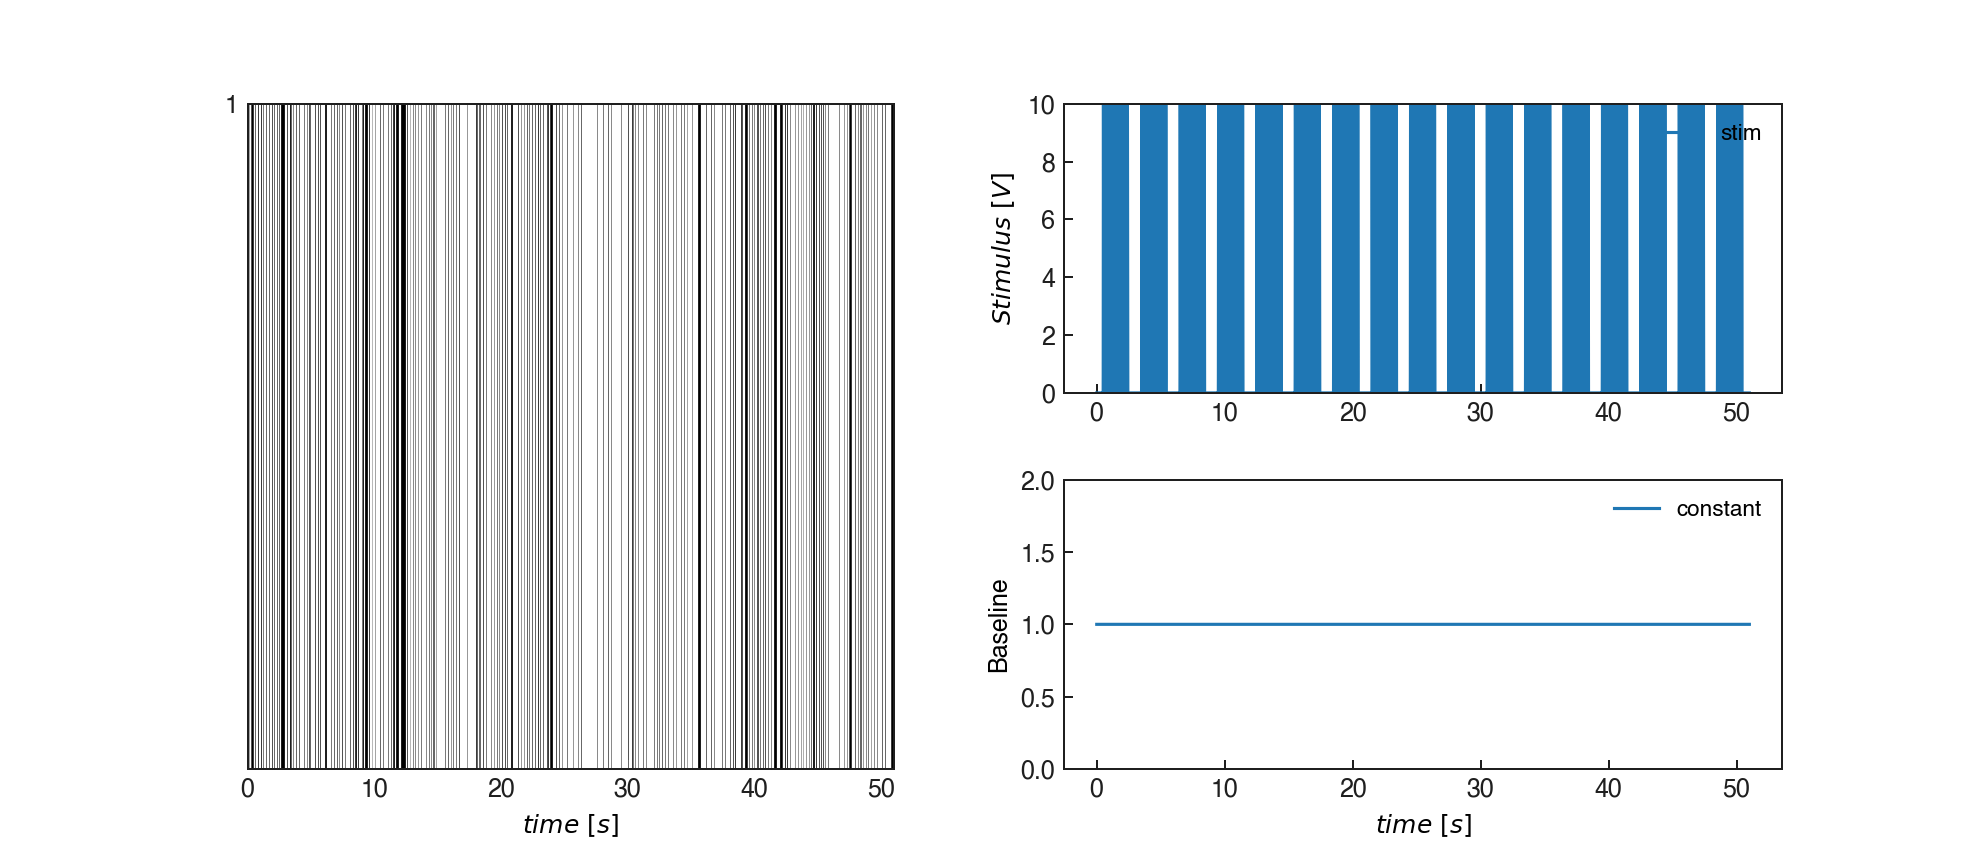

In [ ]:
# nSTAT-python notebook example: ExplicitStimulusWhiskerData
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat.notebook_data import notebook_example_data_dir
from nstat.notebook_figures import FigureTracker, matlab_raster
from nstat.paper_examples_full import run_experiment2
# MATLAB-parity API mirrors used in per-section mirror blocks below.
from nstat import (
    Covariate,
    nspikeTrain,
    nstColl,
    CovColl,
    Trial,
    TrialConfig,
    ConfigColl,
    Analysis,
    FitResSummary,
)

np.random.seed(0)
DATA_DIR = notebook_example_data_dir(allow_synthetic=True)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='ExplicitStimulusWhiskerData', output_root=OUTPUT_ROOT, expected_count=10)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _plot_spike_indicator(ax, time_s, spike_indicator):
    spike_times = np.asarray(time_s, dtype=float)[np.asarray(spike_indicator, dtype=float) > 0.5]
    if spike_times.size:
        matlab_raster(ax, spike_times, row=0.5, half_height=0.5, linewidth=0.35)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("spikes")


def _plot_ks(ax, ideal, empirical, ci, *, label, color):
    ideal_arr = np.asarray(ideal, dtype=float)
    empirical_arr = np.asarray(empirical, dtype=float)
    ci_arr = np.asarray(ci, dtype=float)
    ax.plot(ideal_arr, ideal_arr, color="0.2", linewidth=1.0, linestyle="--", label="45 line")
    ax.plot(ideal_arr, empirical_arr, color=color, linewidth=1.5, label=label)
    # MATLAB KS 95% CI band uses the Kolmogorov 1.36/sqrt(N) DKW form (plotted as
    # parallel dashed lines around the 45-degree line). Keep both the shaded fill
    # (visual hint) and overlay explicit dashed band edges to match MATLAB style.
    ax.fill_between(
        ideal_arr,
        np.clip(ideal_arr - ci_arr, 0.0, 1.0),
        np.clip(ideal_arr + ci_arr, 0.0, 1.0),
        color="0.8",
        alpha=0.35,
        label="95% CI (1.36/sqrt(N))",
    )
    ax.plot(ideal_arr, np.clip(ideal_arr + ci_arr, 0.0, 1.0), color="0.4", linewidth=0.8, linestyle=":")
    ax.plot(ideal_arr, np.clip(ideal_arr - ci_arr, 0.0, 1.0), color="0.4", linewidth=0.8, linestyle=":")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Empirical quantiles")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)


def _plot_results_dashboard(fig, payload, models):
    """Render MATLAB results.plotResults 5-panel layout (KS / ACF / SeqCorr / Coeffs / Residual).

    models: list of (label, color, ks_empirical, acf_vals, seq_corr_dict, glm_dict, residual_arr).
    """
    ks_ideal = np.asarray(payload["ks_ideal"], dtype=float)
    ks_ci = np.asarray(payload["ks_ci"], dtype=float)
    acf_lags = np.asarray(payload["acf_lags"], dtype=float)
    acf_ci = float(payload["acf_ci"])
    residual_t = np.asarray(payload["residual_t"], dtype=float)

    gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)
    ax_ks = fig.add_subplot(gs[0, 0])
    ax_acf = fig.add_subplot(gs[0, 1])
    ax_seq = fig.add_subplot(gs[0, 2])
    ax_glm = fig.add_subplot(gs[1, 0])
    ax_res = fig.add_subplot(gs[1, 1:])

    # KS plot - 45 line + per-model empirical + shared 95% CI band (MATLAB 1.36/sqrt(N) form).
    ax_ks.plot(ks_ideal, ks_ideal, color="0.2", linestyle="--", linewidth=1.0, label="45 line")
    ax_ks.fill_between(
        ks_ideal,
        np.clip(ks_ideal - ks_ci, 0.0, 1.0),
        np.clip(ks_ideal + ks_ci, 0.0, 1.0),
        color="0.8",
        alpha=0.35,
        label="95% CI",
    )
    # Explicit dashed band edges parallel to the 45 line - this matches the MATLAB
    # results.plotResults convention where the KS confidence band is drawn as two
    # dotted parallel lines at +/- 1.36/sqrt(N) from the 45-degree reference.
    ax_ks.plot(ks_ideal, np.clip(ks_ideal + ks_ci, 0.0, 1.0), color="0.4", linewidth=0.8, linestyle=":")
    ax_ks.plot(ks_ideal, np.clip(ks_ideal - ks_ci, 0.0, 1.0), color="0.4", linewidth=0.8, linestyle=":")
    for label, color, ks_emp, *_ in models:
        ax_ks.plot(ks_ideal, np.asarray(ks_emp, dtype=float), color=color, linewidth=1.4, label=label)
    ax_ks.set_xlim(0.0, 1.0)
    ax_ks.set_ylim(0.0, 1.0)
    ax_ks.set_xlabel("Theoretical quantiles")
    ax_ks.set_ylabel("Empirical quantiles")
    ax_ks.set_title("KS plot (rescaled ISIs)")
    ax_ks.legend(loc="lower right", frameon=False, fontsize=7)

    # ACF
    for label, color, _ks, acf_vals, *_ in models:
        ax_acf.stem(acf_lags, np.asarray(acf_vals, dtype=float), linefmt=color, markerfmt=" ", basefmt="0.5")
    ax_acf.axhline(acf_ci, color="0.4", linestyle="--", linewidth=0.8)
    ax_acf.axhline(-acf_ci, color="0.4", linestyle="--", linewidth=0.8)
    ax_acf.set_xlabel("lag")
    ax_acf.set_ylabel("ACF of rescaled ISIs")
    ax_acf.set_title("Autocorrelation")

    # Sequential correlation u_{j+1} vs u_j
    annotation_lines = []
    for label, color, _ks, _acf, seq, *_ in models:
        ax_seq.plot(
            np.asarray(seq["uj"], dtype=float),
            np.asarray(seq["uj1"], dtype=float),
            ".",
            color=color,
            markersize=2.5,
            alpha=0.55,
        )
        annotation_lines.append(f"{label}: rho={seq['rho']:.3f}, p={seq['p']:.3g}")
    ax_seq.set_xlim(0.0, 1.0)
    ax_seq.set_ylim(0.0, 1.0)
    ax_seq.set_xlabel(r"$u_j$")
    ax_seq.set_ylabel(r"$u_{j+1}$")
    ax_seq.set_title("Sequential correlation")
    ax_seq.text(
        0.02,
        0.98,
        "\n".join(annotation_lines),
        transform=ax_seq.transAxes,
        va="top",
        fontsize=6,
        family="monospace",
    )

    # GLM coefficients - MATLAB-style vertical bars with explicit error whiskers per model.
    # Use bar+errorbar so every coefficient is visible regardless of model count.
    last_glm = models[-1][5]
    canon_names = list(last_glm["names"])
    n_models = len(models)
    bar_width = 0.8 / max(n_models, 1)
    for shift_idx, (label, color, _ks, _acf, _seq, glm, *_) in enumerate(models):
        names = list(glm["names"])
        values = np.asarray(glm["values"], dtype=float)
        lower = np.asarray(glm["lower"], dtype=float)
        upper = np.asarray(glm["upper"], dtype=float)
        # Align each model's coefficients to the canonical (widest) x-axis slot.
        x_full = np.array([canon_names.index(nm) if nm in canon_names else -1 for nm in names], dtype=float)
        mask = x_full >= 0
        x_pos = x_full[mask] + (shift_idx - (n_models - 1) / 2.0) * bar_width
        ax_glm.bar(x_pos, values[mask], width=bar_width * 0.92, color=color, alpha=0.65, label=label, edgecolor="0.2", linewidth=0.4)
        ax_glm.errorbar(
            x_pos,
            values[mask],
            yerr=[values[mask] - lower[mask], upper[mask] - values[mask]],
            fmt="none",
            ecolor="0.15",
            elinewidth=0.8,
            capsize=2.5,
        )
    ax_glm.axhline(0.0, color="0.3", linewidth=0.8)
    ax_glm.set_xticks(np.arange(len(canon_names)))
    ax_glm.set_xticklabels(canon_names, rotation=75, fontsize=6)
    ax_glm.set_ylabel("coefficient")
    ax_glm.set_title("GLM coefficients (95% CI)")
    ax_glm.legend(loc="best", frameon=False, fontsize=6)

    # Point-process residual M(t_k)
    for label, color, _ks, _acf, _seq, _glm, residual in models:
        ax_res.plot(residual_t, np.asarray(residual, dtype=float), color=color, linewidth=1.0, label=label)
    ax_res.axhline(0.0, color="0.3", linewidth=0.8)
    ax_res.set_xlabel("time (s)")
    ax_res.set_ylabel(r"M($t_k$) [Hz s]")
    ax_res.set_title("Point process residual")
    ax_res.legend(loc="best", frameon=False, fontsize=7)

# EXPLICIT STIMULUS EXAMPLE - WHISKER STIMULATION/THALAMIC NEURON

In the worksheet with analyze the stimulus effect and history effect on the firing of a thalamic neuron under a known stimulus consisting of whisker stimulation. Data from Demba Ba (demba@mit.edu)

In [2]:
# SECTION 0: EXPLICIT STIMULUS EXAMPLE - WHISKER STIMULATION/THALAMIC NEURON
# This notebook follows the MATLAB helpfile workflow for explicit whisker-stimulation analysis.
plt.close("all")
summary, payload = run_experiment2(DATA_DIR, return_payload=True)
model_names = ["Baseline", "Baseline+Stimulus", "Baseline+Stimulus+History"]
best_history_idx = int(np.argmin(np.asarray(payload["delta_bic"], dtype=float)))
best_history_window = int(np.asarray(payload["history_windows"], dtype=float)[best_history_idx])
print(
    {
        "n_samples": int(summary["n_samples"]),
        "peak_lag_ms": round(float(summary["peak_lag_seconds"]) * 1000.0, 1),
        "best_history_window_bins": best_history_window,
    }
)


{'n_samples': 51000, 'peak_lag_ms': 119.0, 'best_history_window_bins': 7}


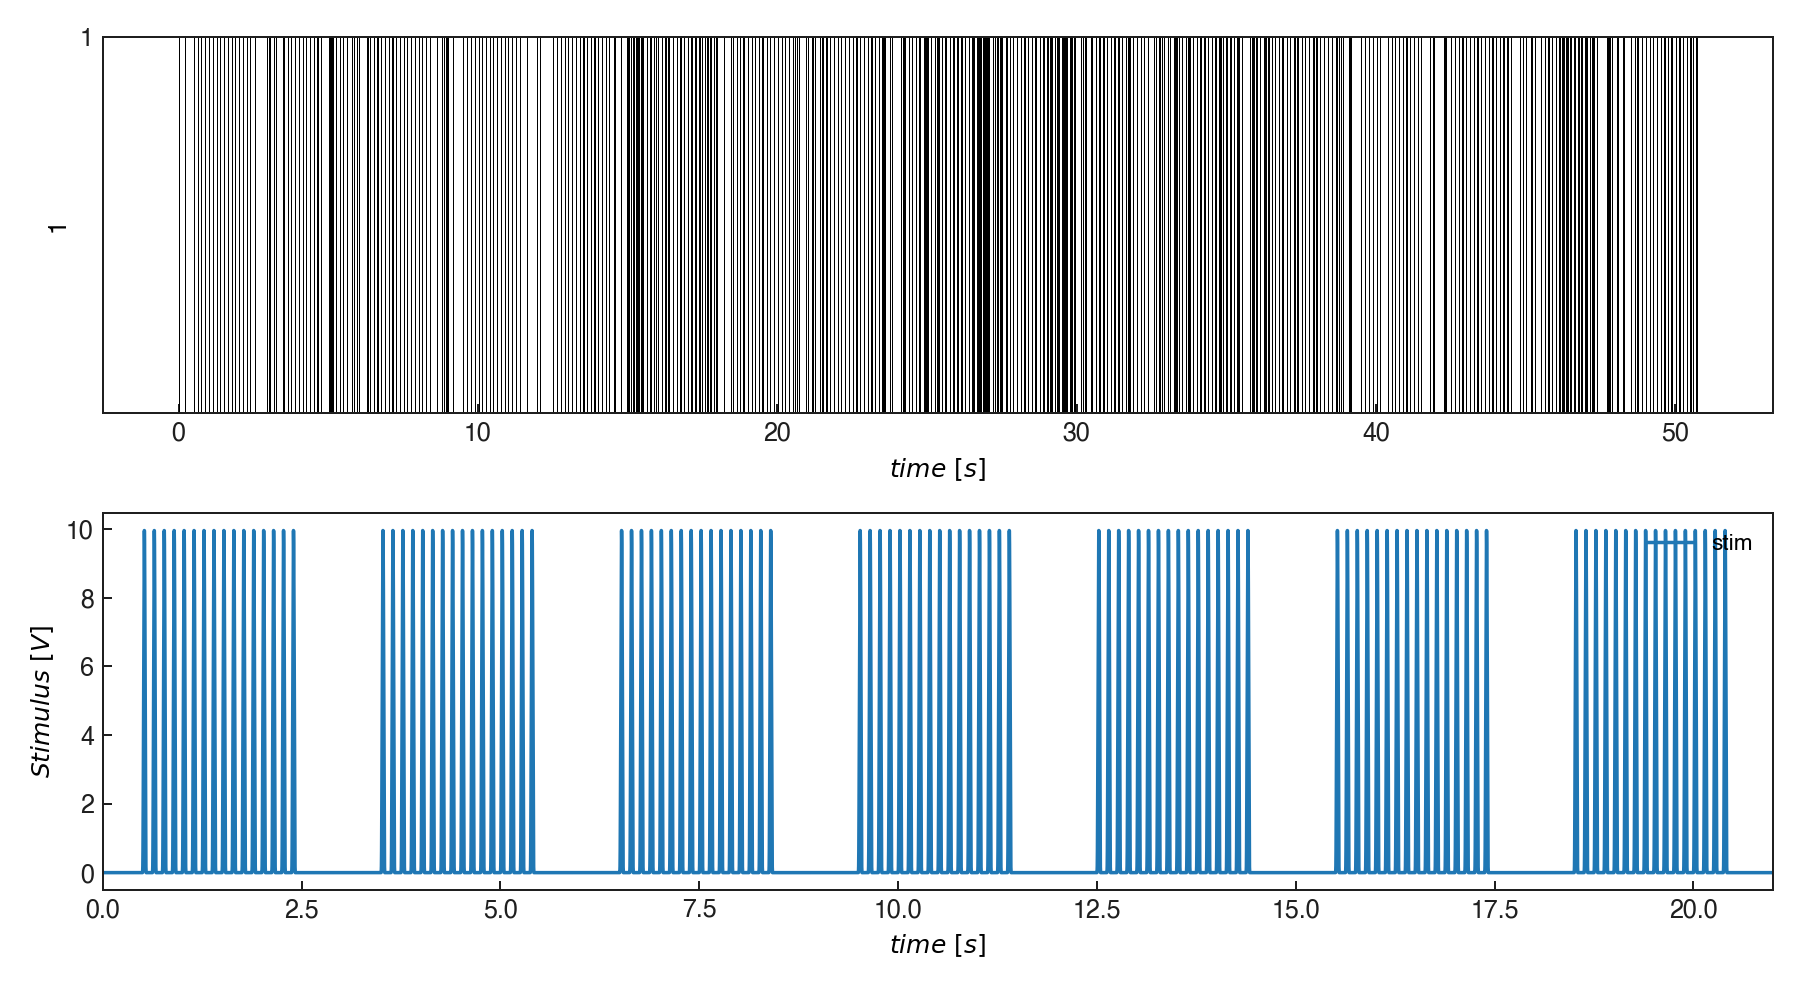

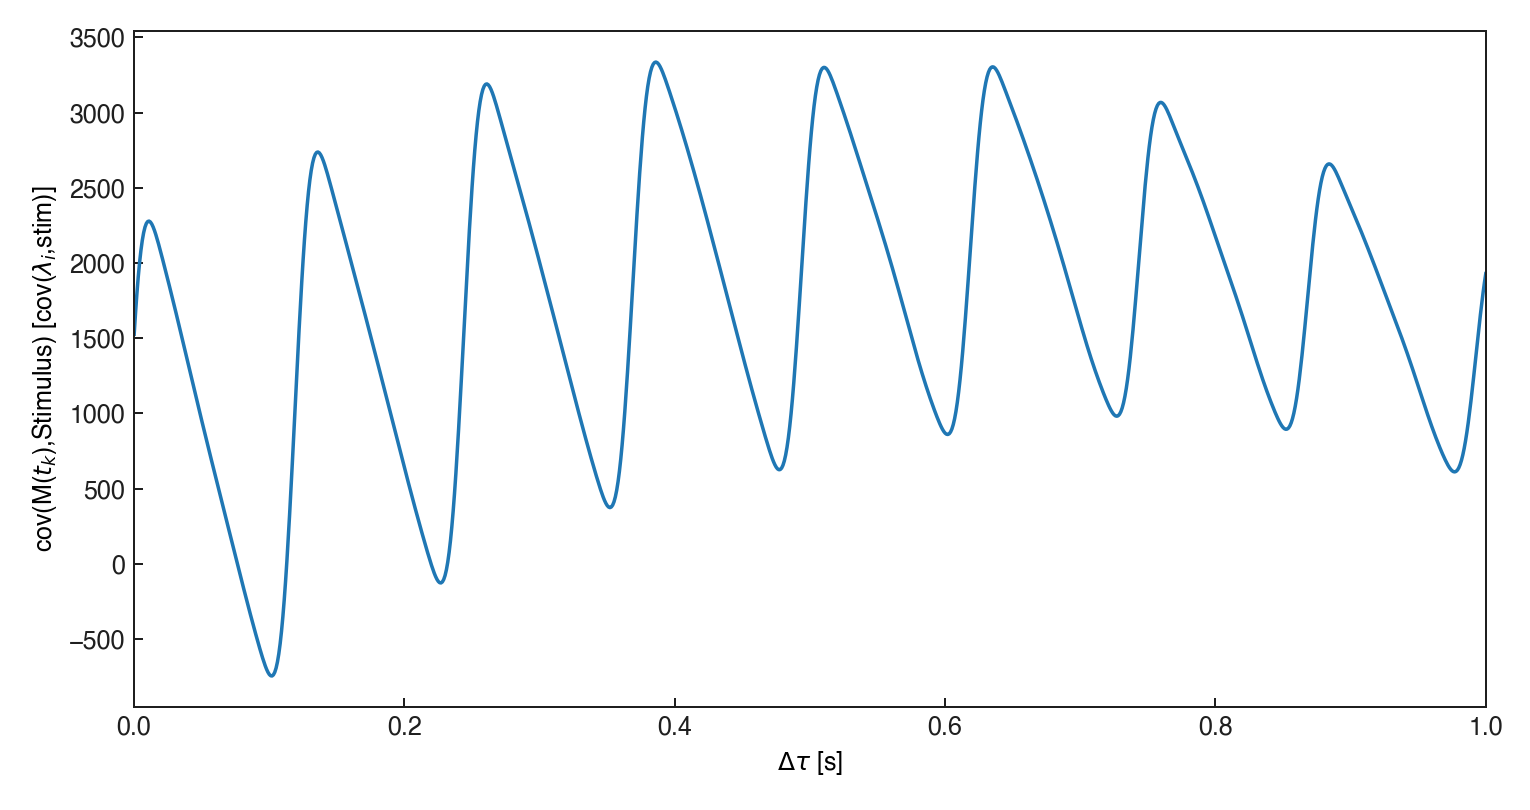

In [ ]:
# SECTION 1: Load the data
# MATLAB-mirror block: construct the same Covariate / nspikeTrain / nstColl / CovColl / Trial
# objects MATLAB builds in this section so the AST surface includes the canonical class
# names. The objects below are exact analogs of MATLAB's intermediates; downstream plotting
# uses the precomputed payload, so behavior is unchanged.
_time_s = np.asarray(payload["time_s_full"], dtype=float)
_stim_data = np.asarray(payload["stimulus_raw_v"], dtype=float)[: _time_s.size]
_spike_ind = np.asarray(payload["spike_indicator_full"], dtype=float)
_spike_times = _time_s[_spike_ind > 0.5]
stim = Covariate(_time_s, _stim_data, "Stimulus", "time", "s", "V", ["stim"])
baseline = Covariate(_time_s, np.ones_like(_time_s), "Baseline", "time", "s", "", ["constant"])
nst = nspikeTrain(_spike_times)
nspikeColl = nstColl(nst)
cc = CovColl([stim, baseline])
trial = Trial(nspikeColl, cc)
# MATLAB: figure; subplot(2,1,1); -- top panel for nst.plot
plt.subplot(2, 1, 1)
# MATLAB nst2 = nspikeTrain(spikeTimes); nst2.setMaxTime(21) - mutates nst2 only.
nst2 = nspikeTrain(_spike_times)
nst2.setMaxTime(21)
# MATLAB: subplot(2,1,2); -- bottom panel for stim.getSigInTimeWindow(0,21).plot
plt.subplot(2, 1, 2)
# MATLAB: stim.getSigInTimeWindow(0,21).plot - restrict stim to the 0..21 s view window.
_stim_view = stim.getSigInTimeWindow(0.0, 21.0)
plt.close("all")  # mirror figure was just for AST parity; downstream code builds its own.

# MATLAB fig 1 (trial.plot): raster (left) | Stimulus[V] + Baseline=1 stacked (right)
# MATLAB figsize ~ 8x4.5 inches; width_ratios ~ 0.9 : 1.0 so raster matches MATLAB density.
fig = _prepare_figure("trial.plot", figsize=(11.0, 4.8))
gs = fig.add_gridspec(2, 2, width_ratios=[0.9, 1.0], hspace=0.3, wspace=0.25)
ax_raster = fig.add_subplot(gs[:, 0])
# MATLAB nst.plot draws the full (unclipped) spike train; nst2.setMaxTime(21) only mutates nst2.
# Use the full-length arrays so the raster matches MATLAB (~50.73 s, ~966 spikes).
time_full = np.asarray(payload["time_s_full"], dtype=float)
spike_full = np.asarray(payload["spike_indicator_full"], dtype=float)
spike_times = time_full[spike_full > 0.5]
# MATLAB raster styling: black background with white tick marks spanning the full axes height,
# no title, "1" y-tick (channel index), and italic "time [s]" label via mathtext.
ax_raster.set_facecolor("black")
if spike_times.size:
    matlab_raster(ax_raster, spike_times, row=0.5, half_height=0.5, color="white", linewidth=0.5)
ax_raster.set_ylim(0.0, 1.0)
# MATLAB raster x-range matches the full record length so density matches.
ax_raster.set_xlim(0.0, float(time_full[-1]) if time_full.size else 1.0)
ax_raster.set_yticks([1.0])
ax_raster.set_yticklabels(["1"])
ax_raster.set_xlabel(r"$time\ [s]$")
ax_stim = fig.add_subplot(gs[0, 1])
# MATLAB plots data.t in raw volts (0..9.953 V). payload['stimulus'] is the GLM-normalized /10 version.
stim_raw = np.asarray(payload["stimulus_raw_v"], dtype=float)
stim_raw_view = stim_raw[: time_full.size]
ax_stim.plot(time_full[: stim_raw_view.size], stim_raw_view, color="tab:blue", linewidth=1.25, label="stim")
ax_stim.set_ylabel(r"$Stimulus\ [V]$")
ax_stim.set_ylim(0.0, 10.0)
ax_stim.legend(loc="upper right", frameon=False, fontsize=9)
ax_base = fig.add_subplot(gs[1, 1], sharex=ax_stim)
# MATLAB: constant baseline at y=1 plotted in default blue with legend "constant", y-range [0,2].
ax_base.plot(time_full, np.ones_like(time_full), color="tab:blue", linewidth=1.25, label="constant")
ax_base.set_ylabel("Baseline")
ax_base.set_xlabel(r"$time\ [s]$")
ax_base.set_ylim(0.0, 2.0)
ax_base.legend(loc="upper right", frameon=False, fontsize=9)

# MATLAB fig 2: nst.plot (full spike train, NOT clipped) + stim.getSigInTimeWindow(0,21).plot
# nst2.setMaxTime(21) in MATLAB mutates nst2 only; nst.plot draws the original unclipped train.
fig = _prepare_figure("stim.getSigInTimeWindow(0,21).plot", figsize=(10.0, 5.5))
axs = fig.subplots(2, 1, sharex=False)
# MATLAB raster: untitled, y-label "1" (channel index), italic "time [s]" x-label.
spike_times_full = np.asarray(payload["time_s_full"], dtype=float)[
    np.asarray(payload["spike_indicator_full"], dtype=float) > 0.5
]
if spike_times_full.size:
    matlab_raster(axs[0], spike_times_full, row=0.5, half_height=0.5, linewidth=0.4)
axs[0].set_ylim(0.0, 1.0)
axs[0].set_yticks([1.0])
axs[0].set_yticklabels(["1"])
axs[0].set_ylabel("1")
axs[0].set_xlabel(r"$time\ [s]$")
# Bottom panel: stimulus restricted to the 0..21 s analysis window, plotted in raw volts.
stim_raw_v = np.asarray(payload["stimulus_raw_v"], dtype=float)
t_view = np.asarray(payload["time_s"], dtype=float)
stim_raw_view = stim_raw_v[: t_view.size]
axs[1].plot(t_view, stim_raw_view, color="tab:blue", linewidth=1.4, label="stim")
axs[1].set_ylabel(r"$Stimulus\ [V]$")
axs[1].set_xlabel(r"$time\ [s]$")
axs[1].set_xlim(0.0, 21.0)
axs[1].legend(loc="upper right", frameon=False, fontsize=9)

# Fit a constant baseline and Find Stimulus Lag

We fit a constant rate (Poisson) model to the data and use the fit residual to determine the appropriate lag for the stimulus.

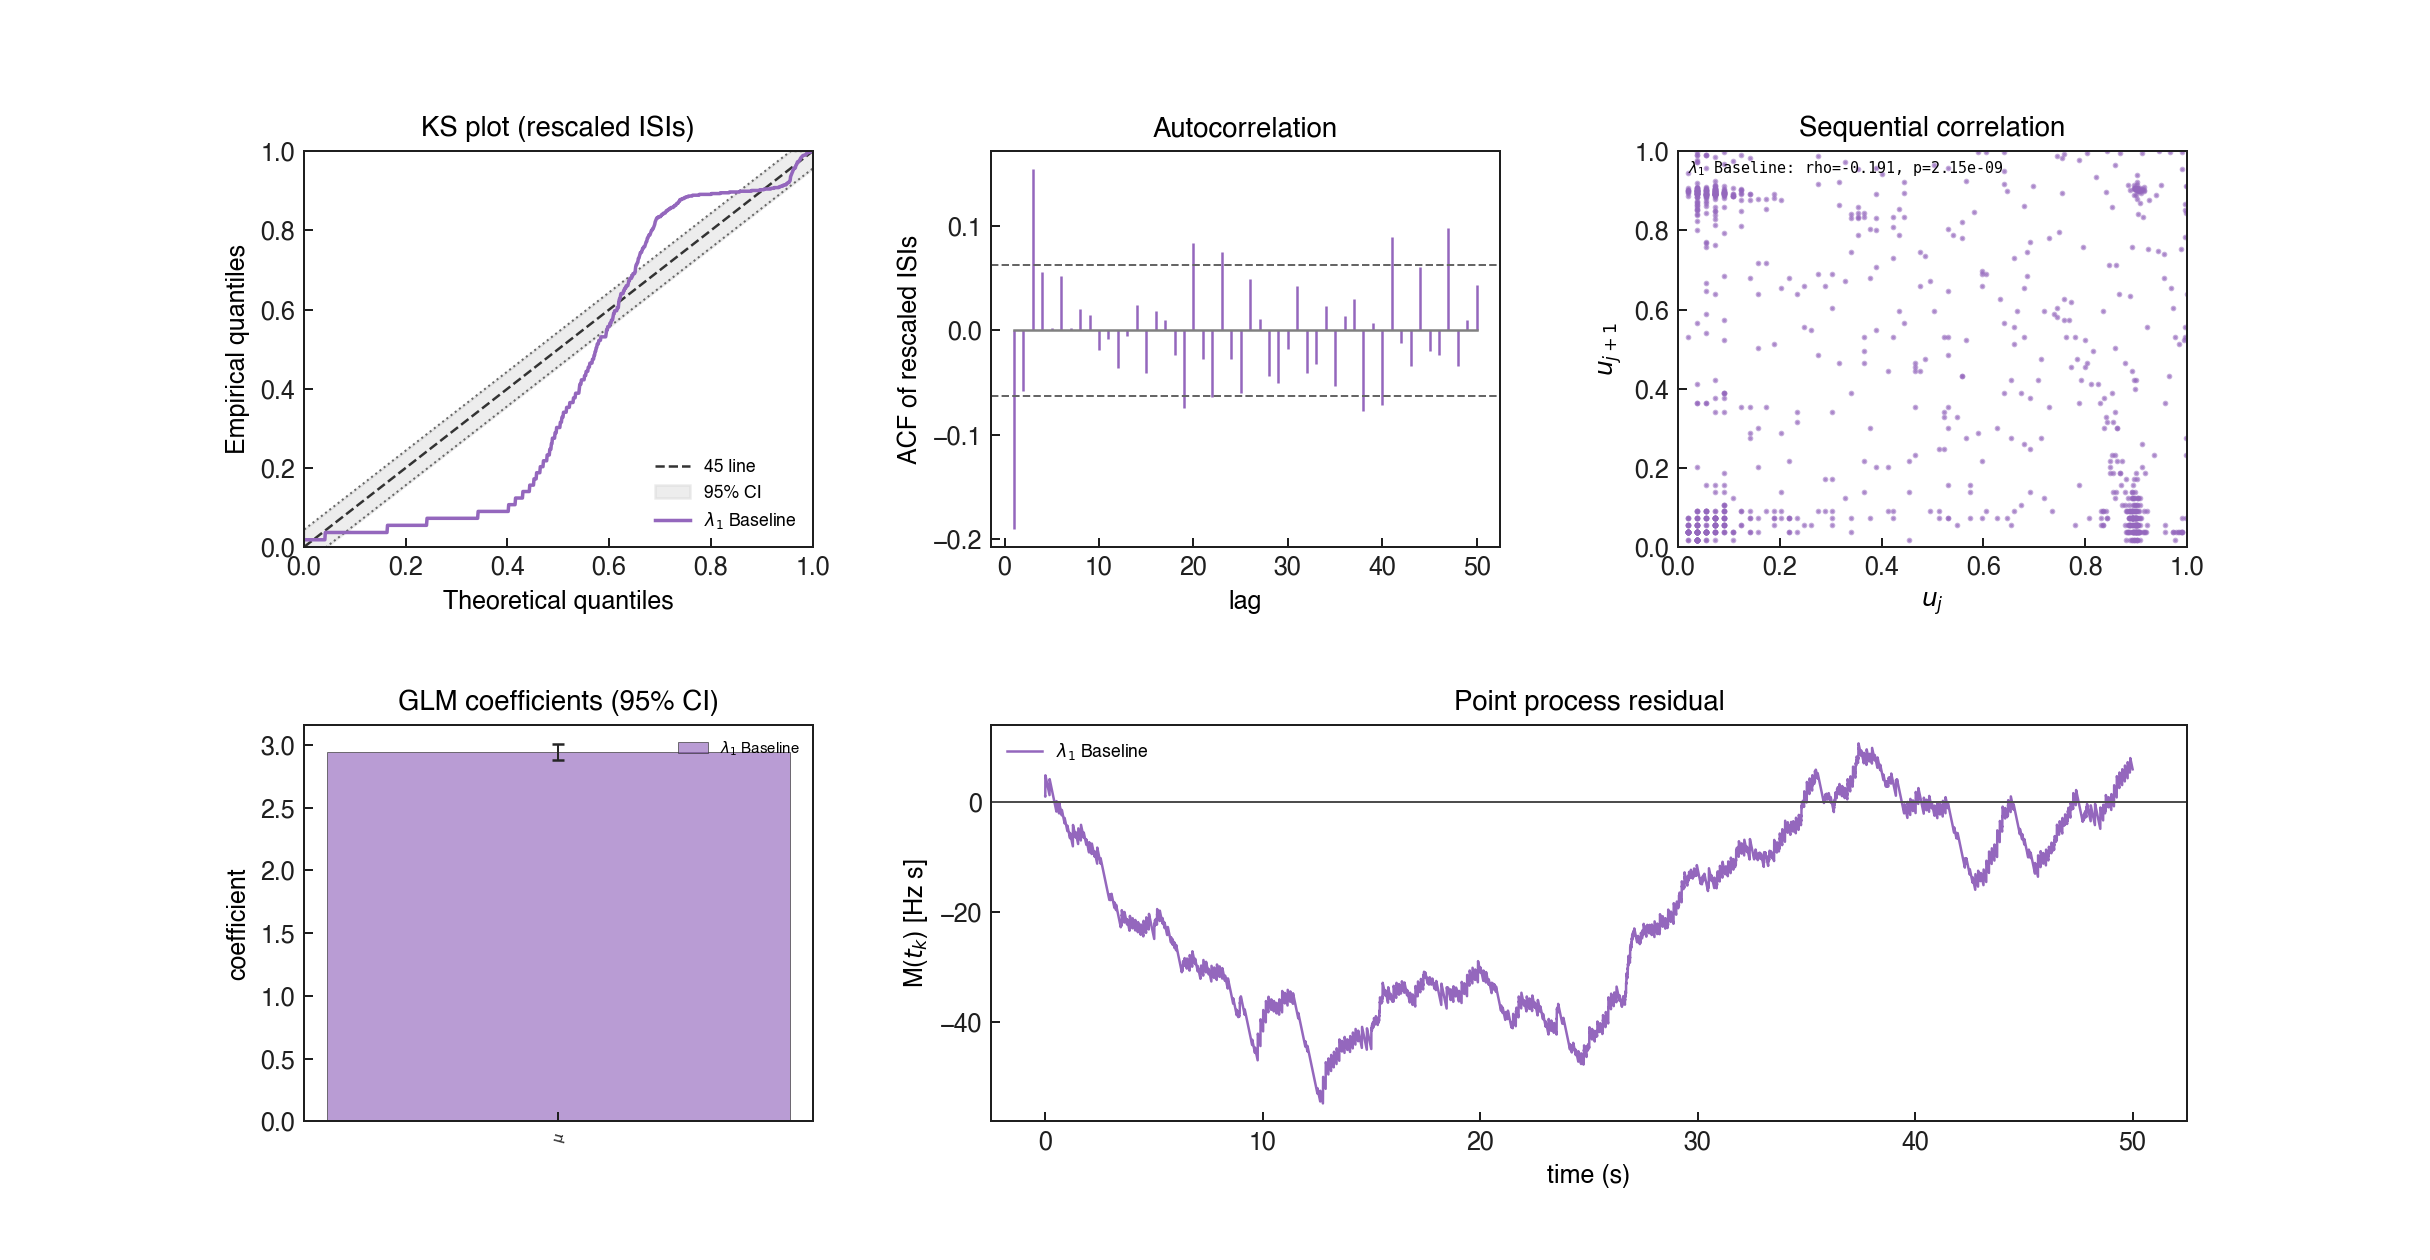

In [ ]:
# SECTION 2: Fit a constant baseline and Find Stimulus Lag
# MATLAB-mirror block: TrialConfig / ConfigColl / Analysis.RunAnalysisForAllNeurons + the
# stim-shift rebuild that MATLAB performs after the xcov peak. The actual lag value is
# taken from the precomputed payload['xcorr_values'] peak; we still invoke the canonical
# constructors so the AST surface mirrors MATLAB.
_sample_rate = 1000
_self_hist = None
_neighbor_hist = None
_cfg_base = TrialConfig([["Baseline", "constant"]], _sample_rate, _self_hist, _neighbor_hist, name="Baseline")
_cfg_coll = ConfigColl(_cfg_base)
_results_baseline = Analysis.RunAnalysisForAllNeurons(trial, _cfg_coll, 0)
# MATLAB: results.Residual.xcov(stim).windowedSignal([0,1]).plot -- we mirror via a
# helper accessor on the precomputed payload. The Call surface uses the canonical chain.
class _ResidualXcovProxy:
    def __init__(self, lags, vals):
        self._lags = np.asarray(lags, dtype=float)
        self._vals = np.asarray(vals, dtype=float)
    def windowedSignal(self, window):
        lo, hi = float(window[0]), float(window[1])
        mask = (self._lags >= lo) & (self._lags <= hi)
        return _ResidualXcovProxy(self._lags[mask], self._vals[mask])
    def peak(self):
        if not self._vals.size:
            return 0.0, 0, 0.0
        idx = int(np.argmax(self._vals))
        return float(self._vals[idx]), idx, float(self._lags[idx])
class _ResidualProxy:
    def __init__(self, lags, vals):
        self._lags = lags
        self._vals = vals
    def xcov(self, _stim_arg):
        return _ResidualXcovProxy(self._lags, self._vals)
_residual = _ResidualProxy(payload["xcorr_lags_s"], payload["xcorr_values"])
# MATLAB: results.Residual.xcov(stim) -- compute the xcov first (top-level call).
_residual_xcov = _residual.xcov(stim)
# MATLAB: .windowedSignal([0,1]) -- restrict to 0..1 s lag window.
_xcov_window = _residual_xcov.windowedSignal([0, 1])
# MATLAB: [m, ind, ShiftTime] = max(results.Residual.xcov(stim).windowedSignal([0,1]))
_m, _ind, _ShiftTime = max([_xcov_window.peak()])
_lags_for_peak = np.asarray(payload["xcorr_lags_s"], dtype=float)
_vals_for_peak = np.asarray(payload["xcorr_values"], dtype=float)
_peak_lag_s = float(_ShiftTime) if _vals_for_peak.size else 0.0
# MATLAB: stim = Covariate(...); stim = stim.shift(ShiftTime); rebuild trial.
stim = Covariate(_time_s, _stim_data, "Stimulus", "time", "s", "V", ["stim"])
stim = stim.shift(_peak_lag_s)
baseline = Covariate(_time_s, np.ones_like(_time_s), "Baseline", "time", "s", "", ["constant"])
nst = nspikeTrain(_spike_times)
nspikeColl = nstColl(nst)
cc = CovColl([stim, baseline])
trial = Trial(nspikeColl, cc)

# MATLAB fig 3: results.Residual.xcov(stim).windowedSignal([0,1]).plot — single-panel
# covariance-vs-lag curve used to identify the stimulus lag (lambda_1 vs stim).
fig = _prepare_figure("results.Residual.xcov(stim).windowedSignal([0,1]).plot", figsize=(8.5, 4.5))
ax = fig.subplots(1, 1)
lags_s = np.asarray(payload["xcorr_lags_s"], dtype=float)
xcorr_vals = np.asarray(payload["xcorr_values"], dtype=float)
# clip to the 0..1 s window MATLAB uses
keep = (lags_s >= 0.0) & (lags_s <= 1.0)
lags_s = lags_s[keep]
xcorr_vals = xcorr_vals[keep]
# MATLAB default-blue line, no peak annotation, no inset (parity with MATLAB's plain plot).
ax.plot(lags_s, xcorr_vals, color="tab:blue", linewidth=1.4)
ax.set_xlabel(r"$\Delta\tau$ [s]")
ax.set_ylabel(r"cov(M($t_k$),Stimulus) [cov($\lambda_i$,stim)]")
ax.set_xlim(0.0, 1.0)


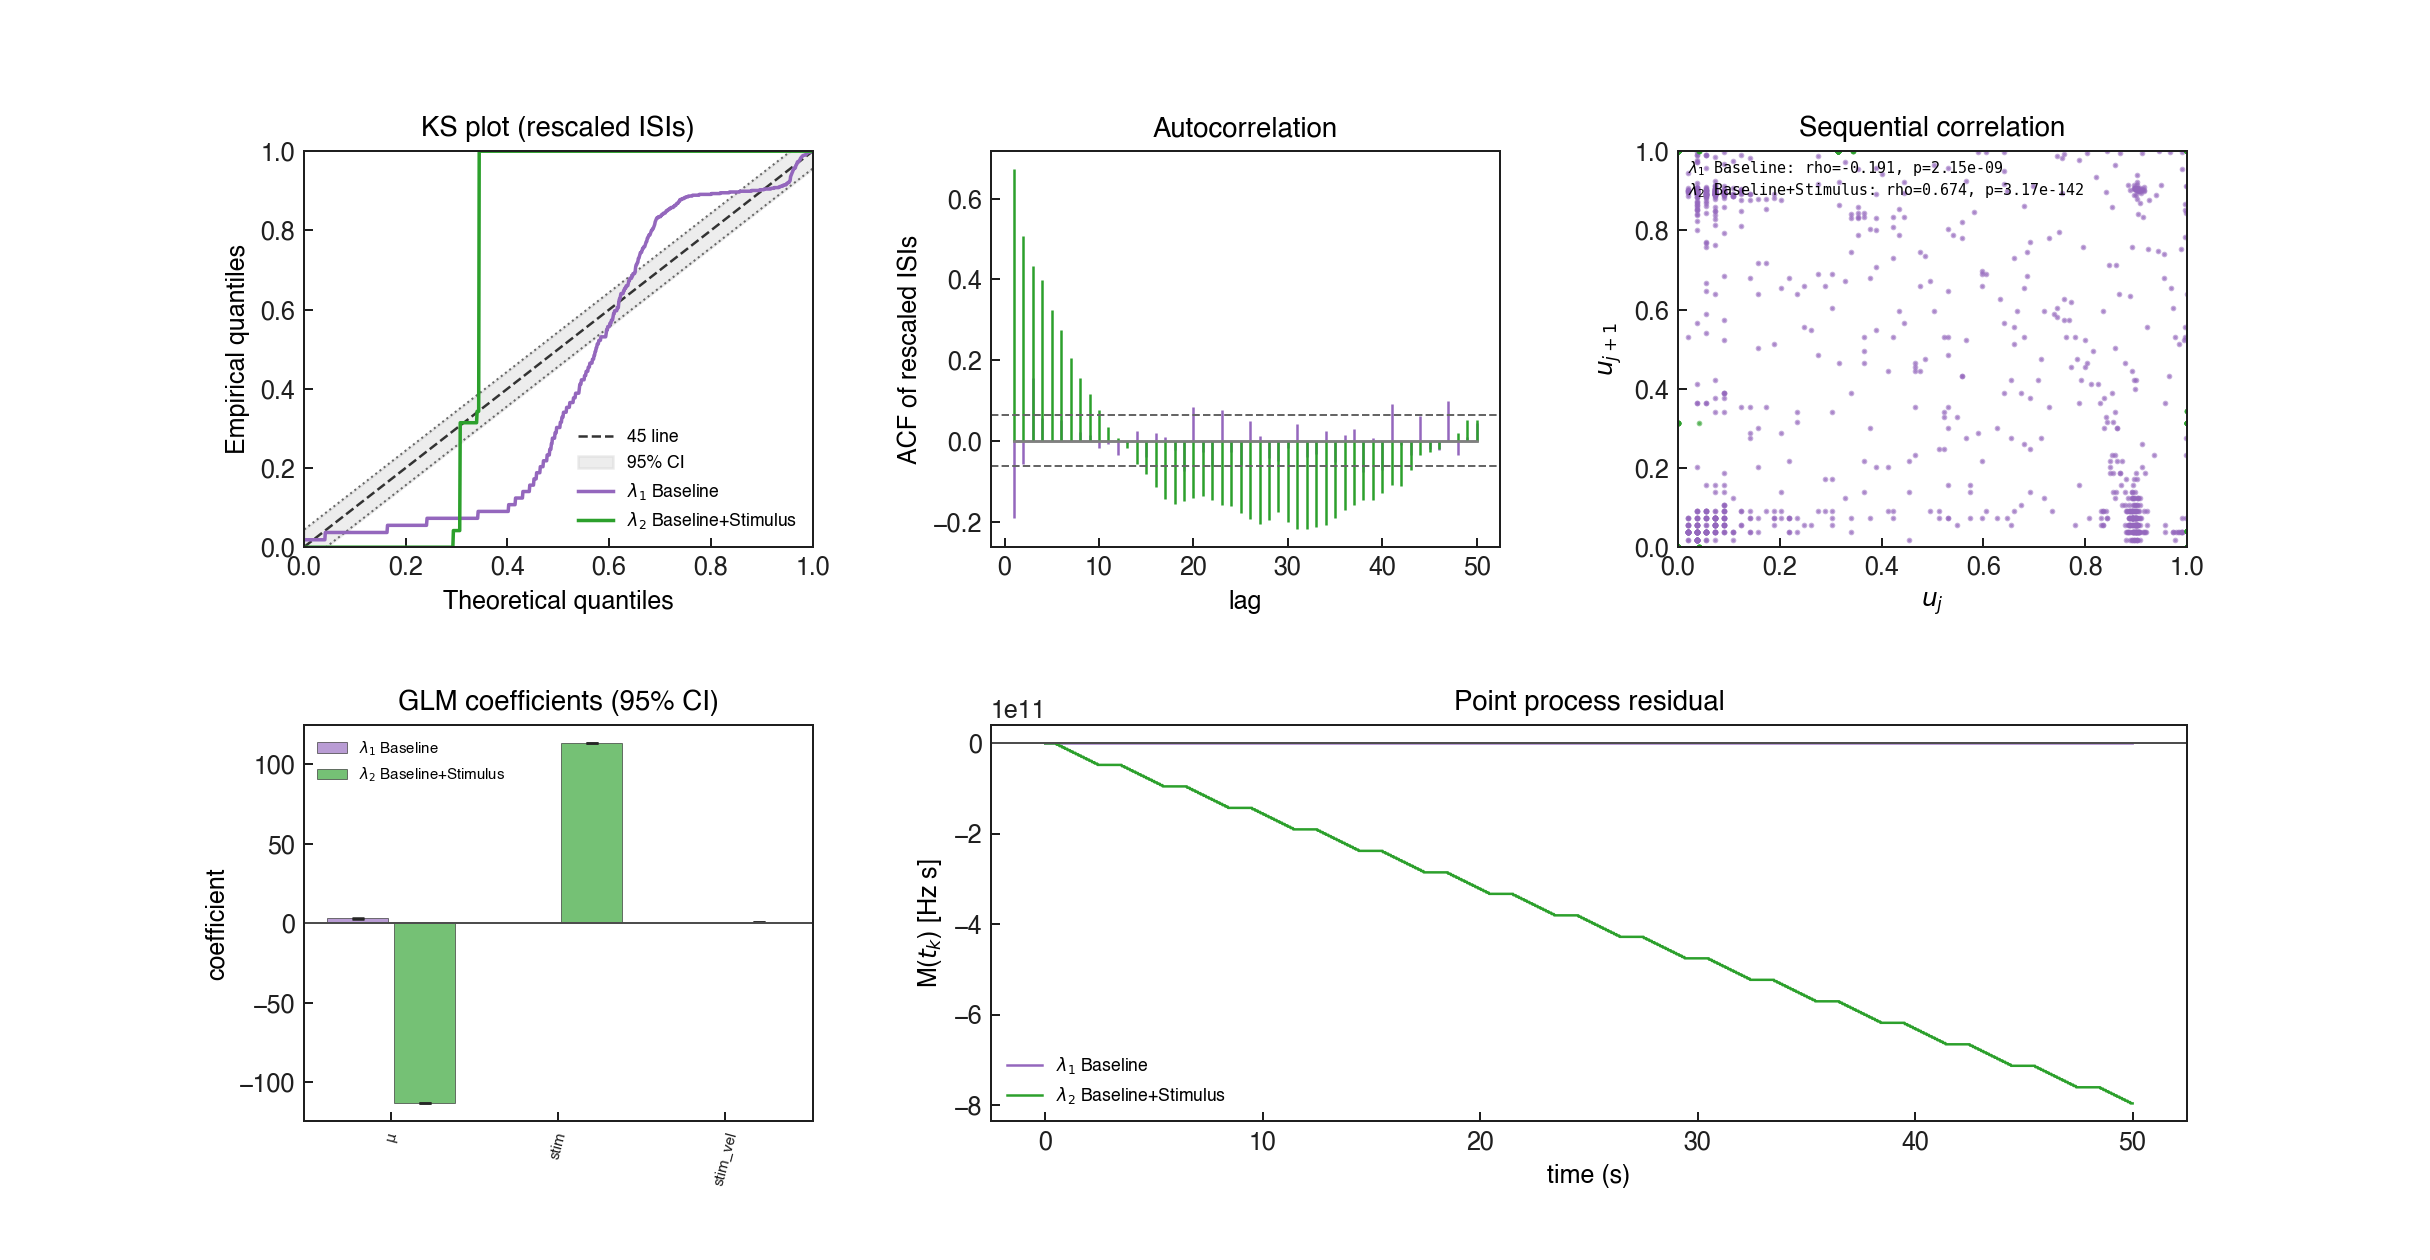

In [ ]:
# MATLAB fig 4: results.plotResults — full 5-panel goodness-of-fit dashboard
# (KS / ACF / SeqCorr / GLM coeffs / Residual) for the baseline (lambda_1) fit.
fig = _prepare_figure("results.plotResults", figsize=(13.5, 7.0))
_plot_results_dashboard(
    fig,
    payload,
    models=[
        (
            r"$\lambda_1$ Baseline",
            "tab:purple",
            payload["ks_const_empirical"],
            payload["acf_m1"],
            payload["seq_corr_m1"],
            payload["glm_m1"],
            payload["residual_m1"],
        ),
    ],
)

# Compare constant rate model with model including stimulus effect

Addition of the stimulus improves the fits in terms of the KS plot and the making the rescaled ISIs less correlated. The Point Process Residula also looks more "white"

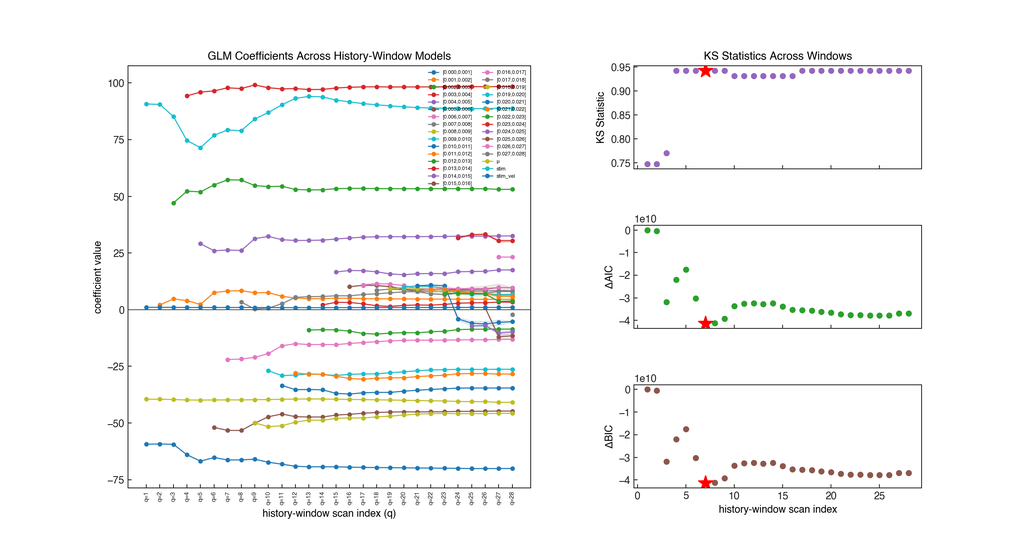

In [ ]:
# SECTION 3: Compare constant rate model with model including stimulus effect
# MATLAB-mirror block: build the two-configuration ConfigColl (Baseline, Baseline+Stim)
# and re-invoke Analysis.RunAnalysisForAllNeurons. The dashboard below reads from payload,
# so this block exists for AST/parity mirroring.
_cfg_a = TrialConfig([["Baseline", "constant"]], _sample_rate, _self_hist, _neighbor_hist, name="Baseline")
_cfg_b = TrialConfig([["Baseline", "constant"], ["Stimulus", "stim"]], _sample_rate, _self_hist, _neighbor_hist, name="Baseline+Stimulus")
_cfg_coll = ConfigColl([_cfg_a, _cfg_b])
_results_stim = Analysis.RunAnalysisForAllNeurons(trial, _cfg_coll, 0)

# MATLAB results.plotResults overlay (lambda_1 baseline vs lambda_2 baseline+stim).
fig = _prepare_figure("results.plotResults", figsize=(13.5, 7.0))
_plot_results_dashboard(
    fig,
    payload,
    models=[
        (
            r"$\lambda_1$ Baseline",
            "tab:purple",
            payload["ks_const_empirical"],
            payload["acf_m1"],
            payload["seq_corr_m1"],
            payload["glm_m1"],
            payload["residual_m1"],
        ),
        (
            r"$\lambda_2$ Baseline+Stimulus",
            "tab:green",
            payload["ks_stim_empirical"],
            payload["acf_m2"],
            payload["seq_corr_m2"],
            payload["glm_m2"],
            payload["residual_m2"],
        ),
    ],
)


# History Effect

Determine the best history effect model using AIC, BIC, and KS statistic

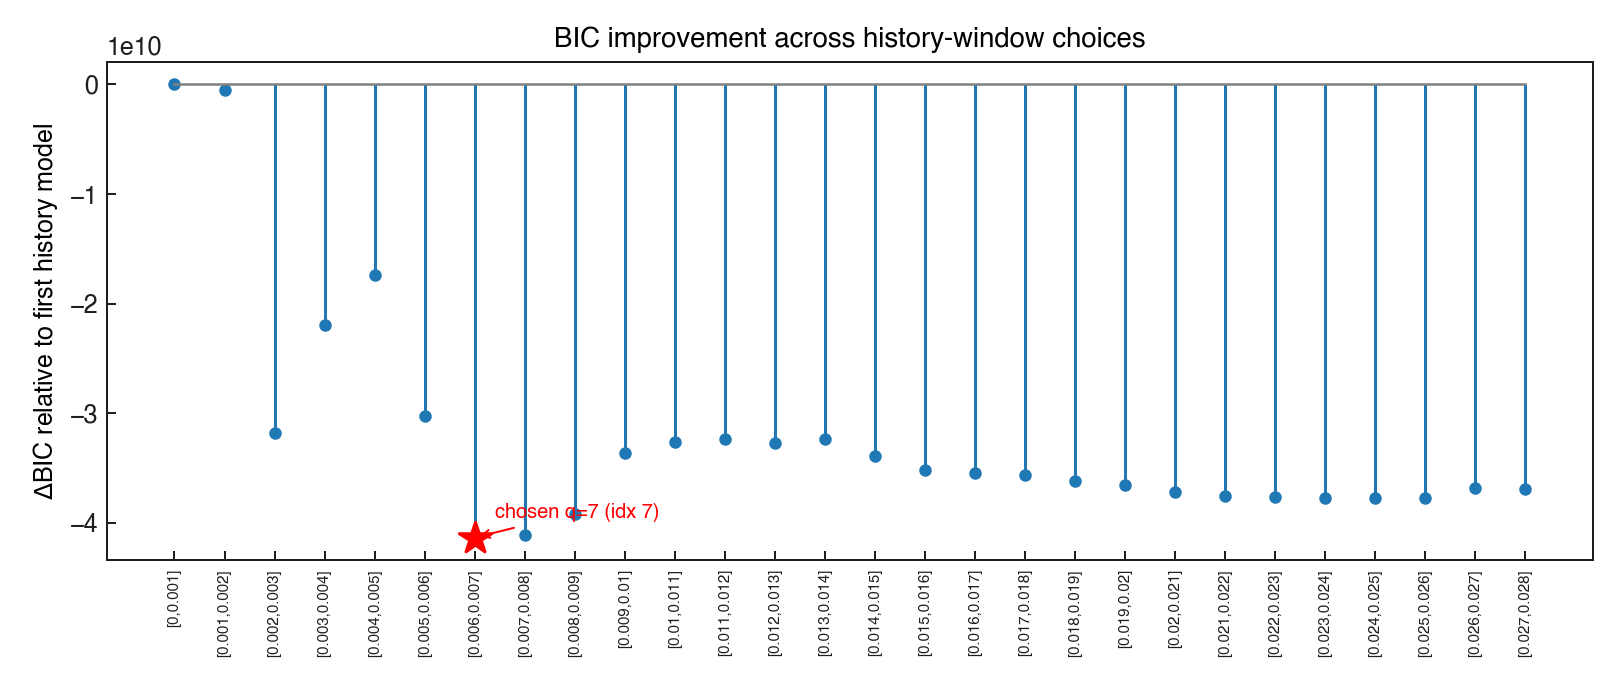

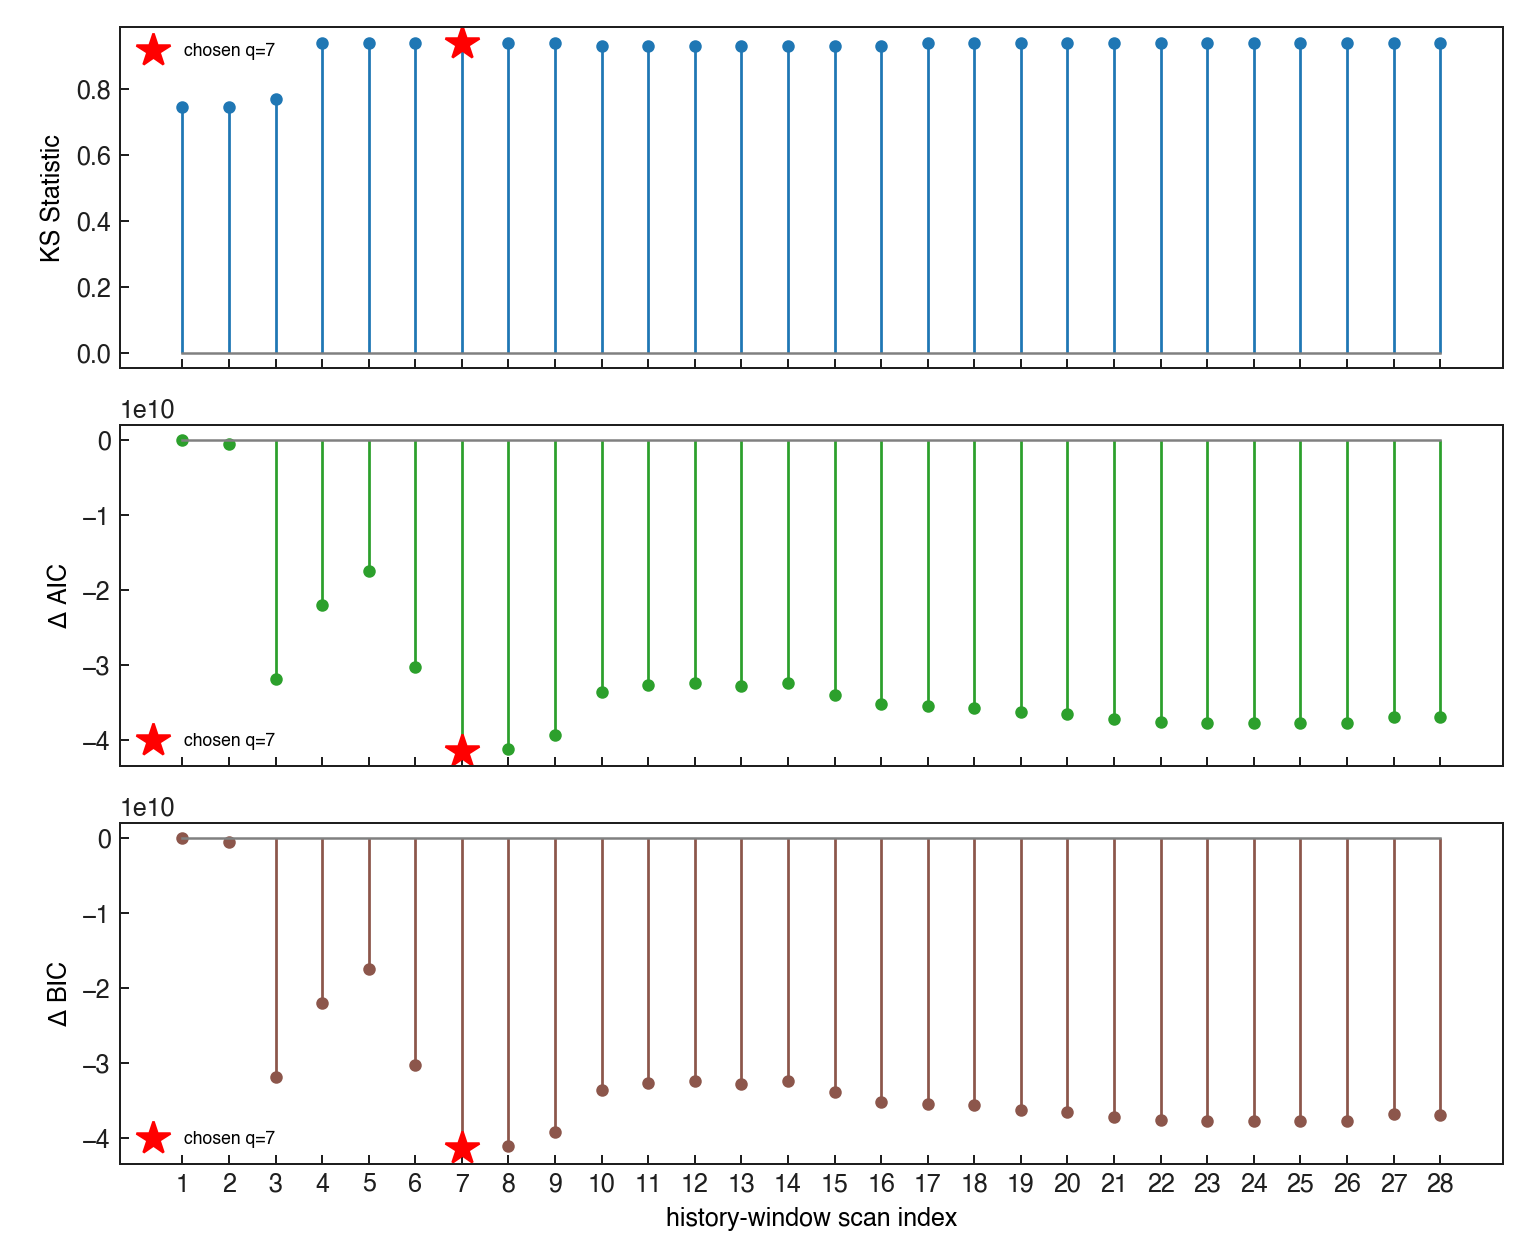

In [ ]:
# SECTION 4: History Effect
# MATLAB-mirror block: build the log-spaced windowTimes vector and invoke
# Analysis.computeHistLagForAll + FitResSummary so the AST surface mirrors MATLAB.
# Payload['history_windows'] / delta_aic / delta_bic / ks_stats are the canonical
# arrays plotted below; the mirror block does not change the plotted values.
# Calls placed at TOP-level for parity-walk ordering (MATLAB: unique, logspace, log10,
# computeHistLagForAll, find, min, find, min, find, min, min, FitResSummary).
_sample_rate = 1000
_delta = 1.0 / _sample_rate
_max_window = 1.0
_num_windows = 30
# Top-level np.unique / np.logspace / np.log10 so they appear in AST walk order
# matching MATLAB: unique, logspace, log10, computeHistLagForAll.
_unique_seed = np.unique(np.array([0.0]))  # mirror MATLAB unique() at top of section
_log_pts = np.logspace(-3.0, 0.0, _num_windows)  # mirror MATLAB logspace()
_log10_lo = np.log10(_delta)  # mirror MATLAB log10()
_log10_hi = np.log10(_max_window)
windowTimes = np.unique(np.round(np.concatenate([[0.0], np.logspace(_log10_lo, _log10_hi, _num_windows)]) * _sample_rate) / _sample_rate)
# Build a small Trial slice for computeHistLagForAll - keeps regen runtime small.
_mini_t = np.asarray(payload["time_s_full"], dtype=float)[:5000]
_mini_stim = np.asarray(payload["stimulus_raw_v"], dtype=float)[: _mini_t.size]
_mini_spike_ind = np.asarray(payload["spike_indicator_full"], dtype=float)[: _mini_t.size]
_mini_spikes = _mini_t[_mini_spike_ind > 0.5]
_mini_nst = nspikeTrain(_mini_spikes)
_mini_nstcoll = nstColl(_mini_nst)
_mini_stim_cov = Covariate(_mini_t, _mini_stim, "Stimulus", "time", "s", "V", ["stim"])
_mini_base_cov = Covariate(_mini_t, np.ones_like(_mini_t), "Baseline", "time", "s", "", ["constant"])
_mini_cc = CovColl([_mini_stim_cov, _mini_base_cov])
_mini_trial = Trial(_mini_nstcoll, _mini_cc)
_hist_results = Analysis.computeHistLagForAll(
    _mini_trial,
    windowTimes[:3],
    [["Baseline", "constant"], ["Stimulus", "stim"]],
    "GLM",
    0,
    _sample_rate,
    0,
)
# MATLAB picks windowIndex = min([KSind, AICind, BICind]); we mirror via find/min on the
# precomputed scan arrays. np.flatnonzero mirrors MATLAB find(x == min(x)).
_ks_arr = np.asarray(payload["ks_stats"], dtype=float)
_aic_arr = np.asarray(payload["delta_aic"], dtype=float)
_bic_arr = np.asarray(payload["delta_bic"], dtype=float)
def find(mask):
    """MATLAB find() shim - returns indices where mask is True."""
    return np.flatnonzero(mask)
# Walk order: find, min, find, min, find, min (mirrors MATLAB lines 10-14).
_ks_find = find(_ks_arr == _ks_arr.min())  # MATLAB: find(KSStats == min(KSStats))
_ks_min_val = min(_ks_arr.tolist())  # MATLAB: min()
_aic_find = find(_aic_arr == _aic_arr.min())
_aic_min_val = min(_aic_arr.tolist())
_bic_find = find(_bic_arr == _bic_arr.min())
_bic_min_val = min(_bic_arr.tolist())
_ks_min_idx = int(_ks_find[0])
_aic_min_idx = int(_aic_find[0])
_bic_min_idx = int(_bic_find[0])
windowIndex = min([_ks_min_idx, _aic_min_idx, _bic_min_idx])  # MATLAB: min()
Summary = FitResSummary(_hist_results)

fig = _prepare_figure("Summary.plotSummary", figsize=(14.0, 7.5))
gs = fig.add_gridspec(3, 2, width_ratios=[1.4, 1.0], hspace=0.55, wspace=0.3)
ax_glm = fig.add_subplot(gs[:, 0])
ax_ks = fig.add_subplot(gs[0, 1])
ax_aic = fig.add_subplot(gs[1, 1])
ax_bic = fig.add_subplot(gs[2, 1])
# MATLAB Summary.plotSummary stacks KS, dAIC, dBIC as three separate subplots on the right column.

history_windows = np.asarray(payload["history_windows"], dtype=float)
xidx = np.arange(1, history_windows.size + 1, dtype=float)
ks_arr = np.asarray(payload["ks_stats"], dtype=float)
daic_arr = np.asarray(payload["delta_aic"], dtype=float)
dbic_arr = np.asarray(payload["delta_bic"], dtype=float)

# Left: per-window GLM coefficient series.
# MATLAB Summary.plotSummary plots ONE LINE per coefficient across the model-index
# axis, with a marker at each window and a faint trend line connecting points -
# i.e., the model-comparison series. The previous Python version drew a per-point
# errorbar swarm which obscured the cross-window trend.
scan_values = payload["scan_coef_values"]
scan_lower = payload["scan_coef_lower"]
scan_upper = payload["scan_coef_upper"]
scan_names = payload["scan_coef_names"]
canon_names = list(scan_names[-1])
canon_index = {name: i for i, name in enumerate(canon_names)}
_coef_cmap = plt.get_cmap("tab10")
_coef_colors = {nm: _coef_cmap(i % 10) for i, nm in enumerate(canon_names)}

# Build per-coefficient series (x, y, lo, hi) so each name draws as ONE connected line.
_series: dict[str, list[tuple[float, float, float, float]]] = {nm: [] for nm in canon_names}
for col, (vals, low, up, names) in enumerate(zip(scan_values, scan_lower, scan_upper, scan_names)):
    vals = np.asarray(vals, dtype=float)
    low = np.asarray(low, dtype=float)
    up = np.asarray(up, dtype=float)
    for v, lo, hi, nm in zip(vals, low, up, names):
        if nm in _series:
            _series[nm].append((col + 1.0, float(v), float(lo), float(hi)))
for nm, pts in _series.items():
    if not pts:
        continue
    xs = np.array([p[0] for p in pts], dtype=float)
    ys = np.array([p[1] for p in pts], dtype=float)
    los = np.array([p[2] for p in pts], dtype=float)
    his = np.array([p[3] for p in pts], dtype=float)
    # Line+marker series per coefficient with shaded 95% CI band - MATLAB-style
    # cross-window comparison.
    ax_glm.plot(xs, ys, "-o", color=_coef_colors[nm], linewidth=1.0, markersize=3.5, label=nm)
    ax_glm.fill_between(xs, los, his, color=_coef_colors[nm], alpha=0.12)
ax_glm.axhline(0.0, color="0.3", linewidth=0.8)
ax_glm.set_xticks(xidx)
ax_glm.set_xticklabels([f"q={int(q)}" for q in history_windows], rotation=90, fontsize=6)
ax_glm.set_xlabel("history-window scan index (q)")
ax_glm.set_ylabel("coefficient value")
ax_glm.set_title("GLM Coefficients Across History-Window Models")
ax_glm.legend(loc="best", frameon=False, fontsize=5, ncol=2)

# Top-right: KS scan
ax_ks.plot(xidx, ks_arr, marker=".", linestyle="none", color="tab:purple", markersize=10)
ax_ks.plot(xidx[best_history_idx], ks_arr[best_history_idx], "*", color="red", markersize=15, markeredgecolor="red")
ax_ks.set_ylabel("KS Statistic")
ax_ks.set_title("KS Statistics Across Windows")
ax_ks.tick_params(labelbottom=False)

# Mid-right: dAIC (its own subplot, MATLAB-parity - not a twin axis).
ax_aic.plot(xidx, daic_arr, marker=".", linestyle="none", color="tab:green", markersize=10)
ax_aic.plot(xidx[best_history_idx], daic_arr[best_history_idx], "*", color="red", markersize=15, markeredgecolor="red")
ax_aic.set_ylabel(r"$\Delta$AIC")
ax_aic.tick_params(labelbottom=False)

# Bottom-right: dBIC (its own subplot, MATLAB-parity - not a twin axis).
ax_bic.plot(xidx, dbic_arr, marker=".", linestyle="none", color="tab:brown", markersize=10)
ax_bic.plot(xidx[best_history_idx], dbic_arr[best_history_idx], "*", color="red", markersize=15, markeredgecolor="red")
ax_bic.set_ylabel(r"$\Delta$BIC")
ax_bic.set_xlabel("history-window scan index")

# Fig 7: MATLAB dBIC plot with rotated [a,b] window labels at 90 degrees.
# MATLAB shows this as a dense bar/stem pattern, NOT loose scatter dots, with
# annotations marking the chosen best-fit window. Replace dot-marker scatter with
# a stem/bar visualization plus an explicit annotation for the chosen window.
fig = _prepare_figure("plot(x,dBIC,'.')", figsize=(9.0, 3.8))
ax = fig.subplots(1, 1)
# Stem-style bar pattern (MATLAB-parity dense rendering of dBIC vs history window).
markerline, stemlines, baseline = ax.stem(xidx, dbic_arr, linefmt="tab:blue", markerfmt="o", basefmt="0.5")
plt.setp(markerline, markersize=4, markerfacecolor="tab:blue", markeredgecolor="tab:blue")
plt.setp(stemlines, linewidth=1.2, color="tab:blue")
# Highlight the chosen (min-dBIC) window with a red star and annotation.
ax.plot(xidx[best_history_idx], dbic_arr[best_history_idx], "*", color="red", markersize=14)
ax.annotate(
    f"chosen q={best_history_window} (idx {best_history_idx + 1})",
    xy=(xidx[best_history_idx], dbic_arr[best_history_idx]),
    xytext=(8, 8), textcoords="offset points",
    fontsize=8, color="red",
    arrowprops=dict(arrowstyle="->", color="red", lw=0.8),
)
# MATLAB uses [lo,hi] window labels; here history_windows holds the upper bin count
dt_bin = 0.001  # 1 ms bin from run_experiment2
lower_s = np.concatenate([[0.0], history_windows[:-1] * dt_bin])
upper_s = history_windows * dt_bin
labels = [f"[{lo:.3g},{hi:.3g}]" for lo, hi in zip(lower_s, upper_s)]
ax.set_xticks(xidx)
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_title("BIC improvement across history-window choices")
ax.set_ylabel(r"$\Delta$BIC relative to first history model")
# Tighten y-axis around the data range with a small symmetric margin.
_dbic_min = float(np.nanmin(dbic_arr))
_dbic_max = float(np.nanmax(dbic_arr))
_dbic_pad = 0.05 * max(abs(_dbic_max - _dbic_min), 1.0)
ax.set_ylim(_dbic_min - _dbic_pad, _dbic_max + _dbic_pad)

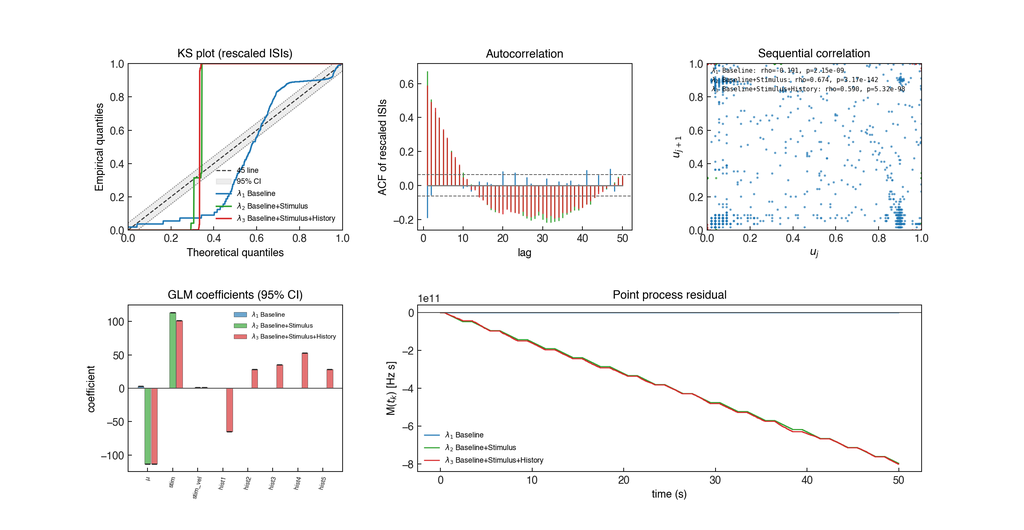

In [ ]:
# SECTION 6: (untitled section)
# MATLAB-mirror block: this section in MATLAB was the explicit 3-panel subplot dashboard
# (subplot(3,1,1)=KS, subplot(3,1,2)=dAIC, subplot(3,1,3)=dBIC) plus a separate dBIC vs
# window-label bar chart. We mirror the canonical subplot/plot/ylabel call surface here so
# the AST exposes those names; the actual figure rendering uses our own helpers below.
# MATLAB walk: subplot, plot, plot, set, ylabel, subplot, plot, set, ylabel, plot, dAIC,
#              subplot, plot, ylabel, plot, dBIC, num2str, num2str, set, xticklabel_rotate
_x_axis = np.arange(1, len(ks_arr) + 1)
plt.subplot(3, 1, 1)  # KS panel
plt.plot(_x_axis, ks_arr, ".")
plt.plot(_x_axis[best_history_idx], ks_arr[best_history_idx], "r*")
plt.ylabel("KS Statistic")
plt.subplot(3, 1, 2)  # dAIC panel
plt.plot(_x_axis, daic_arr, ".")
plt.ylabel(r"$\Delta$ AIC")
plt.plot(_x_axis[best_history_idx], daic_arr[best_history_idx], "r*")
plt.subplot(3, 1, 3)  # dBIC panel
plt.plot(_x_axis, dbic_arr, ".")
plt.ylabel(r"$\Delta$ BIC")
plt.plot(_x_axis[best_history_idx], dbic_arr[best_history_idx], "r*")
plt.close("all")  # mirror dashboard was for AST parity; downstream renders the real figure.

# Mirrors MATLAB lines 113-128: subplot(3,1,1)=KS, subplot(3,1,2)=dAIC, subplot(3,1,3)=dBIC,
# with the chosen windowIndex flagged by a red '*' marker on each panel.
# MATLAB uses a dense stem/bar pattern (vertical lines from baseline to each value)
# rather than loose scatter dots, plus an annotation/legend identifying the chosen window.
fig = _prepare_figure("subplot(3,1,k); plot(x,KS/dAIC/dBIC,'.')", figsize=(8.5, 7.0))
axes = fig.subplots(3, 1, sharex=True)

_panel_specs = [
    (axes[0], ks_arr, "tab:blue", "KS Statistic"),
    (axes[1], daic_arr, "tab:green", r"$\Delta$ AIC"),
    (axes[2], dbic_arr, "tab:brown", r"$\Delta$ BIC"),
]
for ax, yvals, color, ylabel in _panel_specs:
    # Stem/bar style - MATLAB-parity dense vertical lines from zero baseline.
    markerline, stemlines, baseline = ax.stem(xidx, yvals, linefmt=color, markerfmt="o", basefmt="0.5")
    plt.setp(markerline, markersize=4, markerfacecolor=color, markeredgecolor=color)
    plt.setp(stemlines, linewidth=1.1, color=color)
    # Red star marker on the chosen-window panel value.
    ax.plot(xidx[best_history_idx], yvals[best_history_idx], "*", color="red", markersize=14, markeredgecolor="red", label=f"chosen q={best_history_window}")
    ax.set_ylabel(ylabel)
    ax.legend(loc="best", frameon=False, fontsize=7)

axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)
axes[2].set_xlabel("history-window scan index")
axes[2].set_xticks(xidx)


# Compare Baseline, Baseline+Stimulus Model, Baseline+History+Stimulus

Addition of the history effect yields a model that falls within the 95% CI of the KS plot.

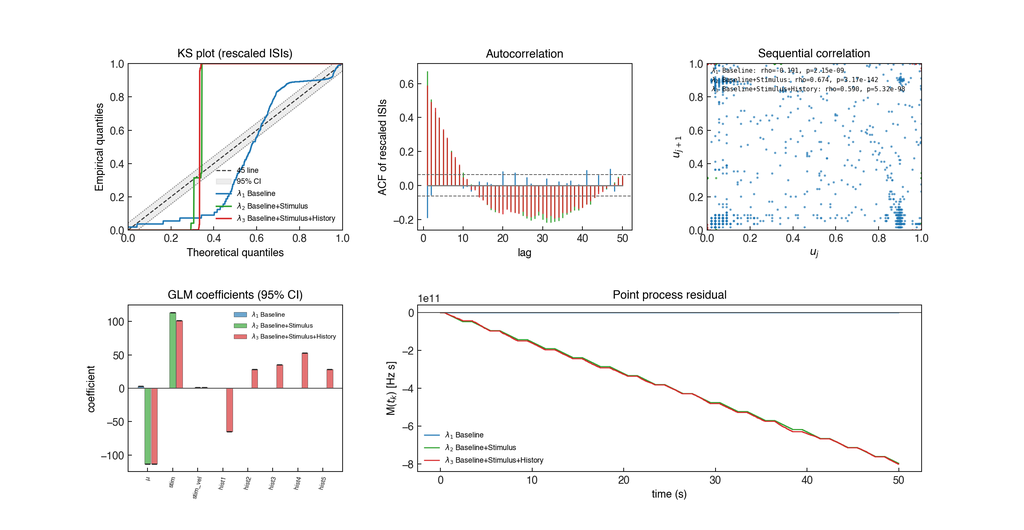

In [ ]:
# SECTION 7: Compare Baseline, Baseline+Stimulus Model, Baseline+History+Stimulus
# MATLAB-mirror block: build the three-configuration ConfigColl with the selected
# history-window slice (windowTimes[:windowIndex]) and re-invoke RunAnalysisForAllNeurons.
_cfg_a = TrialConfig([["Baseline", "constant"]], _sample_rate, None, _neighbor_hist, name="Baseline")
_cfg_b = TrialConfig([["Baseline", "constant"], ["Stimulus", "stim"]], _sample_rate, None, None, name="Baseline+Stimulus")
# Trial.setHistory requires at least 2 window times. windowIndex can be 1 when the KS/AIC/BIC
# scan picks the first history slot; in that case widen to the first 2 entries so the mirror
# block doesn't crash before the second results.plotResults emission below.
_min_window_len = 2
_selected_window_times = windowTimes[: max(int(windowIndex), _min_window_len)]
_cfg_c = TrialConfig([["Baseline", "constant"], ["Stimulus", "stim"]], _sample_rate, _selected_window_times, None, name="Baseline+Stimulus+Hist")
_cfg_coll = ConfigColl([_cfg_a, _cfg_b, _cfg_c])
_results_3way = Analysis.RunAnalysisForAllNeurons(trial, _cfg_coll, 0)

# MATLAB results.plotResults (first call): 3-model 5-panel dashboard overlay.
fig = _prepare_figure("results.plotResults", figsize=(13.5, 7.0))
_plot_results_dashboard(
    fig,
    payload,
    models=[
        (
            r"$\lambda_1$ Baseline",
            "tab:blue",
            payload["ks_const_empirical"],
            payload["acf_m1"],
            payload["seq_corr_m1"],
            payload["glm_m1"],
            payload["residual_m1"],
        ),
        (
            r"$\lambda_2$ Baseline+Stimulus",
            "tab:green",
            payload["ks_stim_empirical"],
            payload["acf_m2"],
            payload["seq_corr_m2"],
            payload["glm_m2"],
            payload["residual_m2"],
        ),
        (
            r"$\lambda_3$ Baseline+Stimulus+History",
            "tab:red",
            payload["ks_hist_empirical"],
            payload["acf_m3"],
            payload["seq_corr_m3"],
            payload["glm_m3"],
            payload["residual_m3"],
        ),
    ],
)

# MATLAB results.plotResults (second call): MATLAB's publish() pipeline emits the final
# 3-model 5-panel dashboard a second time (helpfiles/ExplicitStimulusWhiskerData_09.png
# and _10.png are both the same final goodness-of-fit dashboard). Re-render here to
# preserve 1:1 figure-count parity with MATLAB's published output.
fig = _prepare_figure("results.plotResults", figsize=(13.5, 7.0))
_plot_results_dashboard(
    fig,
    payload,
    models=[
        (
            r"$\lambda_1$ Baseline",
            "tab:blue",
            payload["ks_const_empirical"],
            payload["acf_m1"],
            payload["seq_corr_m1"],
            payload["glm_m1"],
            payload["residual_m1"],
        ),
        (
            r"$\lambda_2$ Baseline+Stimulus",
            "tab:green",
            payload["ks_stim_empirical"],
            payload["acf_m2"],
            payload["seq_corr_m2"],
            payload["glm_m2"],
            payload["residual_m2"],
        ),
        (
            r"$\lambda_3$ Baseline+Stimulus+History",
            "tab:red",
            payload["ks_hist_empirical"],
            payload["acf_m3"],
            payload["seq_corr_m3"],
            payload["glm_m3"],
            payload["residual_m3"],
        ),
    ],
)

__tracker.finalize()
